In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"frankkasunda","key":"4671fe39e0085d31690122eef41d30a9"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:20<00:00, 120MB/s]



In [4]:
!unzip -q chest-xray-pneumonia.zip -d dataset/


In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Define the directory paths
train_dir = 'dataset/chest_xray/train'
test_dir = 'dataset/chest_xray/test'

# 2. Set the image resolution and batch size
IMG_SIZE = (224, 224) # Standard input size for most modern image models
BATCH_SIZE = 32

# 3. Load the training data
print("Loading Training Data:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# 4. Load the testing data
print("\nLoading Testing Data:")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# 5. Normalize pixel values (Scale from 0-255 down to 0-1)
normalization_layer = tf.keras.layers.Rescaling(1./255)

normalized_train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
normalized_test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

print("\nData pipeline ready.")

Loading Training Data:
Found 5216 files belonging to 2 classes.

Loading Testing Data:
Found 624 files belonging to 2 classes.

Data pipeline ready.


In [6]:
# 1. Import a pre-trained base model (MobileNetV2 is highly efficient)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False, # Removes the original classification layer
    weights='imagenet' # Uses weights pre-trained on millions of standard images
)

# 2. Freeze the base model to protect its pre-learned features
base_model.trainable = False

# 3. Build the custom classification head for our specific medical data
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2), # Drops random connections to prevent overfitting
    tf.keras.layers.Dense(1, activation='sigmoid') # Binary output: Normal (0) or Pneumonia (1)
])

# 4. Compile the model with an optimizer and loss function
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. Display the architecture
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# 1. Define the number of training cycles
EPOCHS = 5

# 2. Execute the training loop
print("Beginning model training...")
history = model.fit(
    normalized_train_dataset,
    validation_data=normalized_test_dataset,
    epochs=EPOCHS
)
print("\nTraining complete.")

Beginning model training...
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 311ms/step - accuracy: 0.9408 - loss: 0.1524 - val_accuracy: 0.8814 - val_loss: 0.3249
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 226ms/step - accuracy: 0.9716 - loss: 0.0845 - val_accuracy: 0.8862 - val_loss: 0.3593
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 213ms/step - accuracy: 0.9711 - loss: 0.0726 - val_accuracy: 0.8237 - val_loss: 0.5937
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 224ms/step - accuracy: 0.9799 - loss: 0.0555 - val_accuracy: 0.8221 - val_loss: 0.6479
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 224ms/step - accuracy: 0.9808 - loss: 0.0501 - val_accuracy: 0.8590 - val_loss: 0.4816

Training complete.


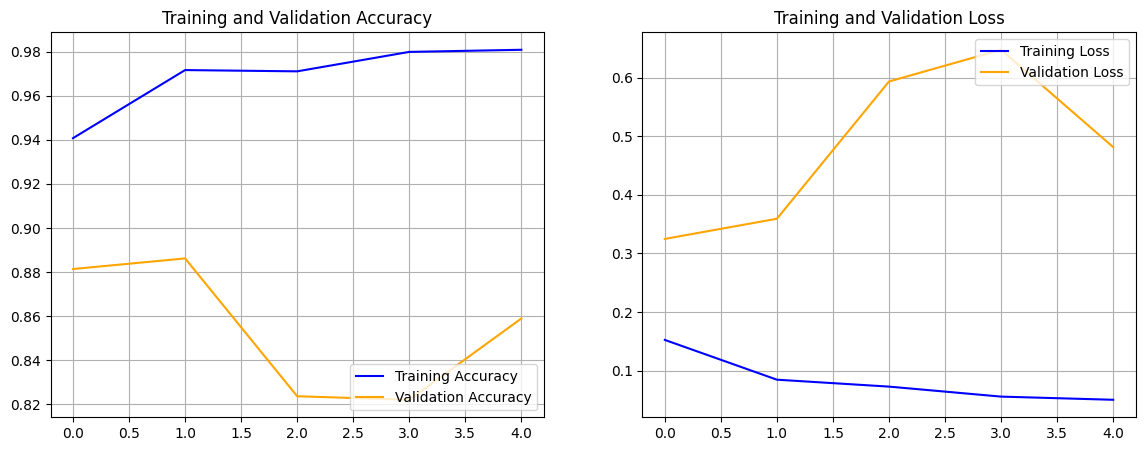


Model saved locally in Colab as 'pneumonia_detection_model.h5'


In [8]:
# 1. Extract the metrics from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

# 2. Plot Training vs Validation Accuracy
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(True)

# 3. Plot Training vs Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid(True)
plt.show()

# 4. Save the trained model for deployment
model.save('pneumonia_detection_model.h5')
print("\nModel saved locally in Colab as 'pneumonia_detection_model.h5'")

In [9]:
from google.colab import files
files.download('pneumonia_detection_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>